# Imports

In [26]:
from torch.utils.data import DataLoader, random_split
import torch
from data import PermutationDataset
from model import PermutationModel
from train import train_one_epoch, evaluate_model
import matplotlib.pyplot as plt

# Parameters
This includes parameters for what to train on and predict, and also the hyperparameters for training.

In [27]:
# Hello world
n = 9
label_name = "stat1"
layers = [2]

epochs = 100
train_split, test_split = 0.8, 0.2
learning_rate = 0.001
momentum = 0.9
batch_size = 64

# Initialization
Initialize the data loaders, model, loss function, optimizers.

In [28]:
full_dataset = PermutationDataset(n, label_name)
training_dataset, test_dataset = random_split(full_dataset, [train_split, test_split])
model = PermutationModel(n, layers)
loss_fn = torch.nn.CrossEntropyLoss(full_dataset.class_weights())
optimizer = torch.optim.SGD(model.parameters(), lr=learning_rate, momentum=momentum)
training_loader = DataLoader(training_dataset, batch_size=batch_size, shuffle=True)
losses = []

# Training loop
Train the model for the appropriate number of epochs and then save the model in `models`.

In [29]:
for epoch in range(epochs):
    model.train(True)
    current_loss = train_one_epoch(training_loader, model, loss_fn, optimizer)
    print(f"Epoch {epoch}, Loss {current_loss}")
    losses.append(current_loss)

torch.save(model.state_dict(), f"models/{label_name}_{n}.pt")

x = 5

Epoch 0, Loss 638.7409129142761
Epoch 1, Loss 126.79649889282882
Epoch 2, Loss 73.0329346852377
Epoch 3, Loss 51.39446121454239
Epoch 4, Loss 39.65779047971591
Epoch 5, Loss 32.288058946374804
Epoch 6, Loss 27.224043244030327
Epoch 7, Loss 23.538259795866907
Epoch 8, Loss 20.725296879187226
Epoch 9, Loss 18.51626353384927
Epoch 10, Loss 16.733908200636506
Epoch 11, Loss 15.258155789226294
Epoch 12, Loss 14.026874659117311
Epoch 13, Loss 12.977734813233837
Epoch 14, Loss 12.074362053535879
Epoch 15, Loss 11.289455400547013
Epoch 16, Loss 10.597883426817134
Epoch 17, Loss 9.987186452606693
Epoch 18, Loss 9.444741592393257
Epoch 19, Loss 8.956399170332588
Epoch 20, Loss 8.51722453464754
Epoch 21, Loss 8.11804259114433
Epoch 22, Loss 7.754616412916221
Epoch 23, Loss 7.421941915410571
Epoch 24, Loss 7.117791469558142
Epoch 25, Loss 6.8370567705715075
Epoch 26, Loss 6.577942966716364
Epoch 27, Loss 6.336977673578076
Epoch 28, Loss 6.113538942066953
Epoch 29, Loss 5.9057425938081
Epoch 30, Lo

# Print the loss curve
Visualize the loss curve to ensure that the model is learning correctly. Save the loss curve in `figures/` so that you can refer to them later.

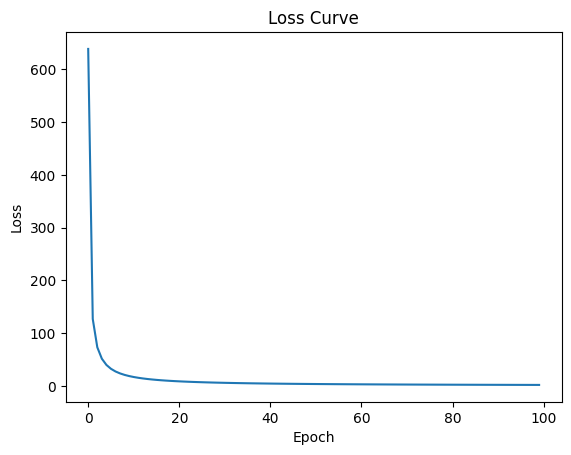

In [30]:
# TODO
# Create a figure and axis
fig, ax = plt.subplots()

# Plot the loss curve
ax.plot(range(len(losses)), losses)

# Add labels and title
ax.set_xlabel('Epoch')
ax.set_ylabel('Loss')
ax.set_title('Loss Curve')


fig.savefig(f'figures/loss_curve_stat1_{n}.png', dpi=300)
# Show the plot
plt.show()

# Evaluate the model
Compute the confusion matrix on the train and test dataset and print out the accuracy and plot the confusion matrix.

In [31]:
# TODO
confusion_matrix = evaluate_model(model, test_dataset)
confusion_matrix.print_accuracy()

Accuracy for class 0 = 100.0%
Accuracy for class 1 = 100.0%
Overall accuracy = 100.0%


# Plot model weights and connections.
Plot the model weights and connections in order to attempt to interpret what the model is learning.

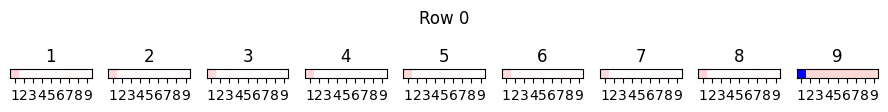

In [32]:
model.plot_heatmap_feature(0,0)